# Export cell tables 

This is a notebook to extract marker counts and morphological information from all the cells in your images based on CellPose segmentations
- Version: 1.5
- Last update: 2024.03.15
- Author (adapting): Yu-Le Wu
- Source: *1_Segment_Image_Data.ipynb* in ark-analysis v0.7.1

In [1]:
# import required packages
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import skimage.io as io
from skimage.io import imread, imsave
from skimage.measure import regionprops_table, label
import xarray as xr
from alpineer import io_utils
import pandas as pd

from ark.segmentation import marker_quantification, segmentation_utils
from ark.utils import (deepcell_service_utils, example_dataset,
                       plot_utils)

## 0: Set root directory and download example dataset

Here we are using the example data located in `/data/example_dataset/input_data`. To modify this notebook to run using your own data, simply change `base_dir` to point to your own sub-directory within the data folder.

* `base_dir`: the path to all of your imaging data. This directory will contain all of the data generated by this notebook.

In [2]:
# set up the base directory
base_dir = "/Users/amir/analysis"
project_name = "CRC_CellTable_v2"

If you would like to test the features in Ark with an example dataset, run the cell below. It will download a dataset consisting of 11 FOVs with 22 channels. You may find more information about the example dataset in the [README](../README.md#example-dataset).

If you are using your own data, skip the cell below.

* `overwrite_existing`: If set to `False`, it will not overwrite existing data in the `data/example_dataset`. Recommended leaving as `True` if you are doing a clean run of the `ark` pipeline using this dataset from the start. If you already have the dataset downloaded, set to `False`.

## 1: set file paths and parameters

### All data, images, files, etc. must be placed in the 'data' directory, and referenced via '../data/path_to_your_data'

If you're interested in directly interfacing with Google Drive, consult the documentation [here](https://ark-analysis.readthedocs.io/en/latest/_rtd/google_docs_usage.html).

In [3]:
# set up file paths
project_dir = os.path.join(base_dir, project_name)
tiff_dir = os.path.join(base_dir, project_name, "image_data")
cell_table_dir = os.path.join(project_dir, "segmentation","cell_table")
deepcell_input_dir = os.path.join(project_dir, "segmentation","cellpose_input_CLAHE")
deepcell_output_dir = os.path.join(project_dir, "segmentation","cellpose_output")
deepcell_visualization_dir = os.path.join(project_dir, "segmentation","cellpose_visualization")

In [4]:
# create directories if do not exist
for directory in [cell_table_dir, deepcell_input_dir, deepcell_output_dir, deepcell_visualization_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)

In [5]:
# validate paths
io_utils.validate_paths([project_dir,
                         tiff_dir,
                         deepcell_input_dir,
                         deepcell_output_dir,
                         cell_table_dir,
                         deepcell_visualization_dir
                         ])

### Compute and filter fov paths

In [6]:
os.chdir(base_dir)
imageData_dir = os.path.join(base_dir, project_name, "segmentation","cellpose_input_CLAHE")
fovs = [f for f in os.listdir(imageData_dir) if not f.startswith('.')]

# If you only segmented a portion of the FOVs based on a keyword run this:
#keyword = "05_dwell"
#fovs = [item for item in fovs if keyword in item]



## 2: Image export and value computing
### We can then save the segmented mask overlaid on the imaging data

display the first image `A_7p_C01_R01` as an example:


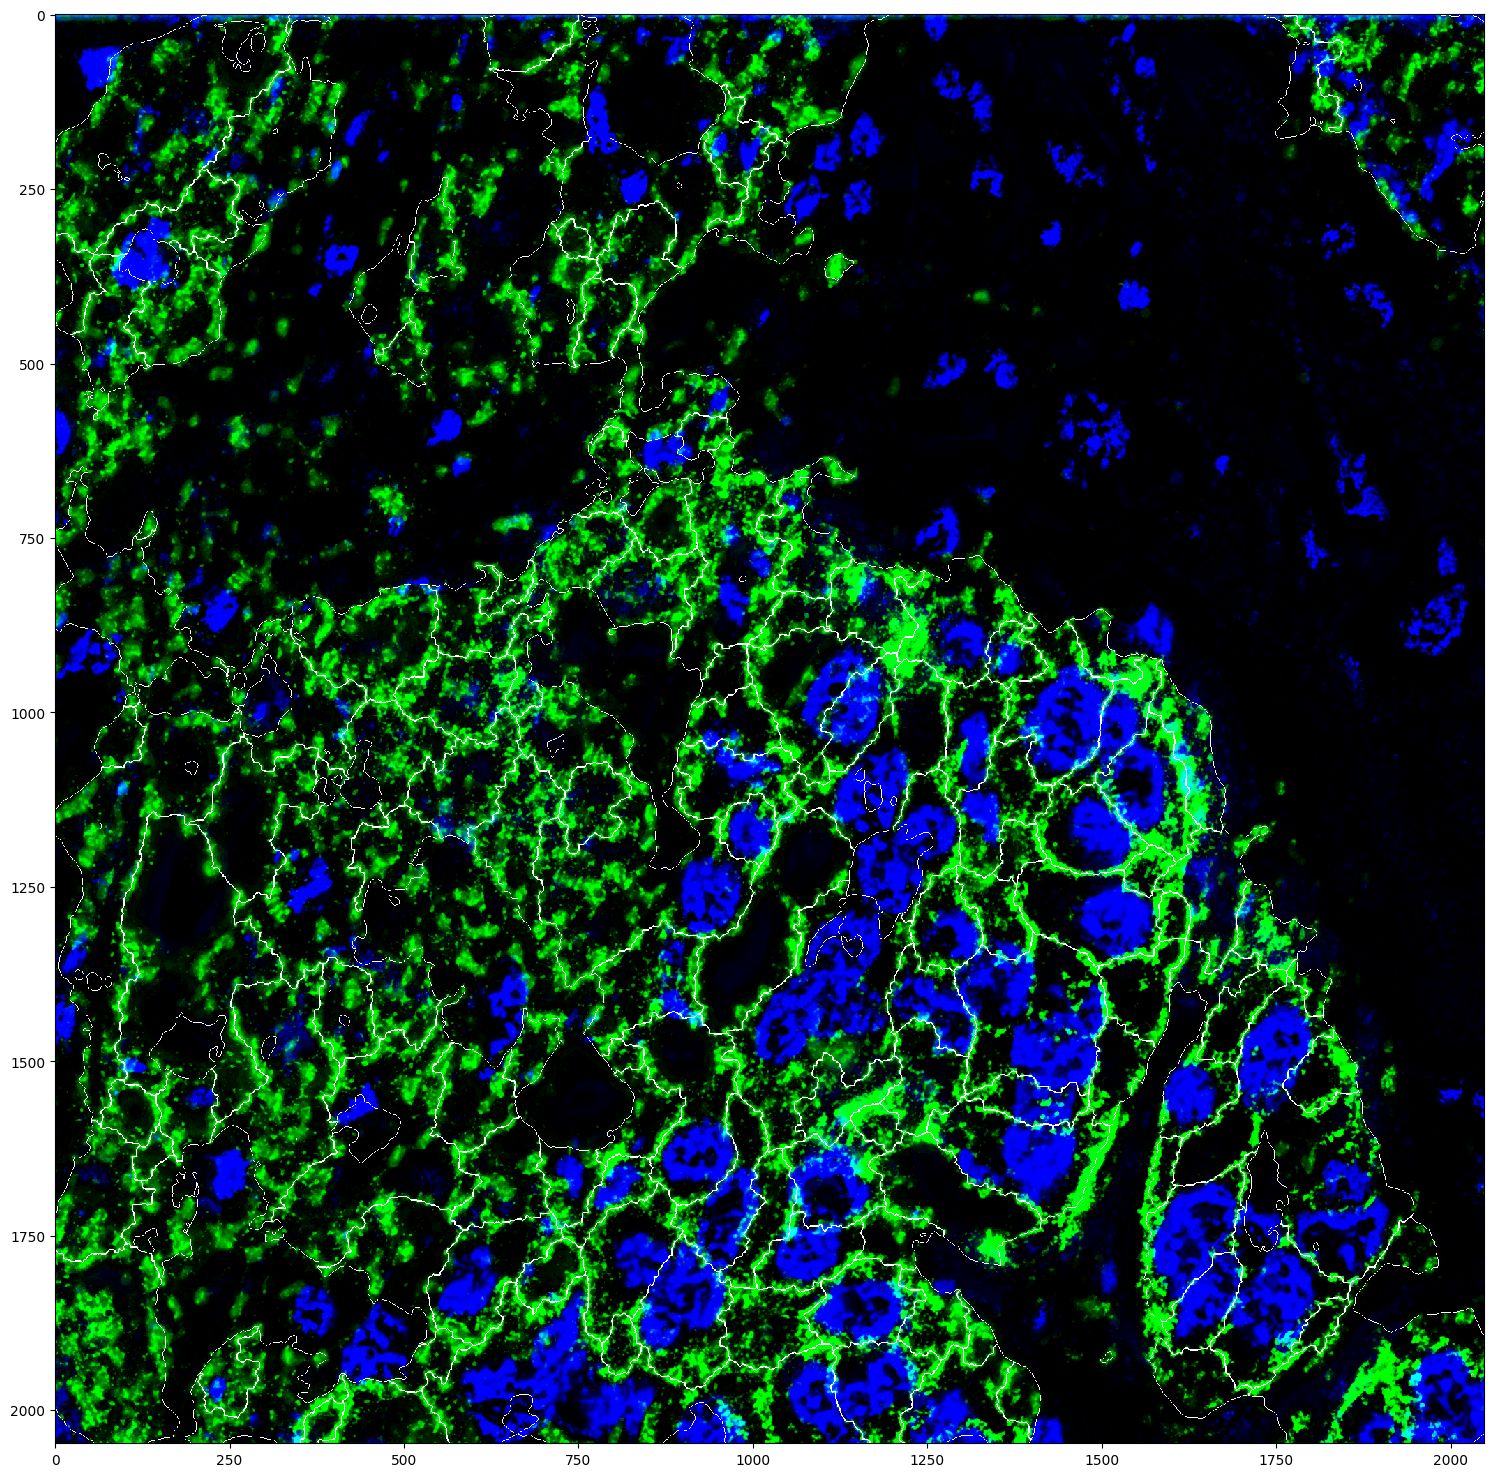

In [7]:
# display the channel overlay for a fov, useful for quick verification
warnings.simplefilter("ignore")

fov_to_display = io_utils.remove_file_extensions([fovs[0]])[0]

fov_overlay = plot_utils.create_overlay(
    fov=fov_to_display,
    segmentation_dir=deepcell_output_dir,
    data_dir=deepcell_input_dir,
    img_overlay_chans=['nuclear_channel', 'membrane_channel'],
    seg_overlay_comp='whole_cell'
)
print(f"display the first image `{fov_to_display}` as an example:")

# Specify figsize
plt.figure(figsize=(15,15))
_ = io.imshow(fov_overlay)


In [8]:
# save the overlaid segmentation labels for each fov (these will not display, but will save in viz_dir)
segmentation_utils.save_segmentation_labels(
    segmentation_dir=deepcell_output_dir,
    data_dir=deepcell_input_dir,
    output_dir=deepcell_visualization_dir,
    fovs=io_utils.remove_file_extensions(fovs),
    channels=['nuclear_channel', 'membrane_channel']
)

### Afterwards, we can generate expression matrices from the labeling + imaging data

In [9]:
# set to True to add nuclear cell properties to the expression matrix
nuclear_counts = True

# set to True to bypass expensive cell property calculations
# only cell label, size, and centroid will be extracted if True
fast_extraction = False

For a full list of features extracted, please refer to the cell table section of: https://ark-analysis.readthedocs.io/en/latest/_rtd/data_types.html

In [10]:
# now extract the segmented imaging data to create normalized and transformed expression matrices
# note that if you're loading your own dataset, please make sure all the imaging data is in the same folder
# with each fov given its own folder and all fovs having the same channels
cell_table_size_normalized, cell_table_arcsinh_transformed = \
    marker_quantification.generate_cell_table(segmentation_dir=deepcell_output_dir,
                                              tiff_dir=tiff_dir,
                                              img_sub_folder=None,
                                              fovs=fovs,
                                              batch_size=5,
                                              nuclear_counts=nuclear_counts,
                                              fast_extraction=fast_extraction)

In [11]:
def postive_pixelcount(regional_mask, image):
    return np.sum(image[regional_mask]>0)

def get_nuclear_pixelcount(segmentation, image):
    label_image = segmentation
    table = regionprops_table(label_image, image, properties=('label',), extra_properties=(postive_pixelcount,))
    return pd.DataFrame.from_dict(table)

def get_fov_nuclear_pixelcount(fov):
    seg = imread(os.path.join(deepcell_output_dir, fov+'_whole_cell.tiff'))
    nuc = imread(os.path.join(deepcell_output_dir, fov+'_nuclear.tiff'))
    df = get_nuclear_pixelcount(seg, nuc)
    df.loc[:,'fov'] = fov
    return df

def add_nuclear_pixelcount_to_celltable(celltable, fovs):
    for k, fov in enumerate(fovs):
        fov = fov.rstrip('.tiff')
        print(fov)
        df_fov = get_fov_nuclear_pixelcount(fov)
        if k == 0:
            df = df_fov
        else:
            df = pd.concat([df, df_fov], ignore_index = True)
    celltable = celltable.merge(df, how='left', on=['fov','label'])
    celltable = celltable.rename(columns={"postive_pixelcount": "nucleus_area"})
    return celltable

In [12]:
cell_table_size_normalized = add_nuclear_pixelcount_to_celltable(cell_table_size_normalized, fovs)

A_7p_C01_R01
B_6d_C01_R01
B_6c_C01_R01
B_9l_C01_R01
E_5c_C01_R01
B_2c_C01_R01
B_8i_C01_R01
B_2d_C01_R01
B_1b_C01_R01
B_4g_C01_R01
A_4q_C01_R01
C_3k_C01_R01
A_9e_C01_R01
A_3h_C01_R01
B_8o_C01_R01
B_2b_C01_R01
A_4h_C01_R01
C_5i_C01_R01
B_6b_C01_R01
C_3m_C01_R01
A_9c_C01_R01
B_5d_C01_R01
A_9d_C01_R01
A_3n_C01_R01
E_6c_C01_R01
A_8f_C01_R01
B_4f_C01_R01
B_6p_C01_R01
B_4l_C01_R01
B_4k_C01_R01
C_3g_C01_R01
B_2p_C01_R01
A_3d_C01_R01
B_5n_C01_R01
B_6o_C01_R01
A_5g_C01_R01
B_5q_C01_R01
B_7m_C01_R01
A_4e_C01_R01
B_8e_C01_R01
C_3a_C01_R01
C_3f_C01_R01
A_6g_C01_R01
B_5o_C01_R01
B_4m_C01_R01
A_7b_C01_R01
C_4g_C01_R01
A_8r_C01_R01
C_5e_C01_R01
B_9f_C01_R01
A_5f_C01_R01
B_6n_C01_R01
A_6e_C01_R01
C_6a_C01_R01
C_3c_C01_R01
B_7n_C01_R01
B_8f_C01_R01
B_7i_C01_R01
C_4e_C01_R01
B_5r_C01_R01
B_9c_C01_R01
B_3i_C01_R01
B_6k_C01_R01
B_3n_C01_R01
A_8i_C01_R01
B_4n_C01_R01
A_7a_C01_R01
B_6r_C01_R01
B_5l_C01_R01
C_3b_C01_R01
C_3e_C01_R01
B_3h_C01_R01
A_5b_C01_R01
C_5f_C01_R01
B_7h_C01_R01
B_8g_C01_R01
B_7o_C01_R01

In [14]:
# Set the compression level if desired, ZSTD compression can offer up to a 60-70% reduction in file size.
# NOTE: Compressed `csv` files cannot be opened in Excel. They must be uncompressed beforehand.
compression = None

# Uncomment the line below to allow for compressed `csv` files.
# compression = {"method": "zstd", "level": 3}

cell_table_size_normalized.to_csv(os.path.join(cell_table_dir, 'cell_table_size_normalized.csv'),
                                  compression=compression, index=False)
cell_table_arcsinh_transformed.to_csv(os.path.join(cell_table_dir, 'cell_table_arcsinh_transformed.csv'),
                                      compression=compression, index=False)